# Figures

Publication figures for the anti-diabetic peptide classifier in my dissertation.

Every figure is built from an exported CSV in `results/` or `screening/`, never by refitting a model.

Outputs go to `figures/` as a matched pair: PDF (vector, for reasearch proj) and PNG at 400 dpi (for slides or also reaserch proj).

In [1]:
# Shared style and save helper for every figure in this notebook.
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Okabe-Ito palette, safe under colour-vision deficiency and in greyscale print
BLUE, VERMILLION, GREY = "#0072B2", "#D55E00", "#999999"

plt.rcParams.update({
    "figure.dpi": 110, # on-screen preview only
    "savefig.dpi": 400, # raster export
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})


def save_figure(fig, name):
    """Write one figure to figures/ as both PDF and PNG."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    print(f"saved {name}.pdf and {name}.png")

## Figure 4. Consensus reliability diagram

Sources `screening/consensus_calibration.csv`, the per-bin table written by Phase 5.0.

Point area is proportional to the number of out-of-fold peptides in each bin, so the eye weights
the bins the way the ECE weights them. The dotted line marks the 0.90 discovery threshold applied
in Phase 5.3. ECE is recomputed here from the per-bin table and cross-checked against the value
Phase 5.0 persisted, so a mismatch between the two files fails the cell rather than passing quietly.

saved figure_4_consensus_calibration.pdf and figure_4_consensus_calibration.png


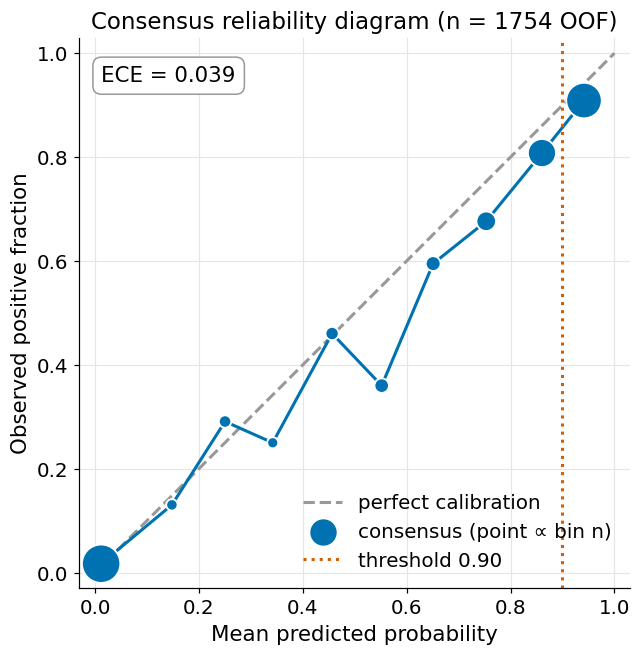

In [2]:
DISCOVERY_THRESHOLD = 0.90 # the cutoff applied in phase5.3, not the 0.87 the sweep permits

rel = pd.read_csv("screening/consensus_calibration.csv")

# ECE is the bin-count-weighted mean gap, recoverable from the exported table alone
ece = ((rel.n / rel.n.sum()) * (rel.mean_pred - rel.obs_pos).abs()).sum()
n_oof = int(rel.n.sum())

# cross-check against the value phase5.0 wrote
summary = pd.read_csv("results/phase5_0_calibration_summary.csv").set_index("quantity")["value"]
assert abs(ece - float(summary["ece_consensus_oof"])) < 5e-4, "ECE drift between table and summary"

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, 1], [0, 1], ls="--", color=GREY, label="perfect calibration")
ax.plot(rel.mean_pred, rel.obs_pos, color=BLUE, zorder=2)
ax.scatter(rel.mean_pred, rel.obs_pos, s=1.2 * rel.n, color=BLUE, edgecolor="white",
           linewidth=1.2, zorder=3, label="consensus (point \u221d bin n)")
ax.axvline(DISCOVERY_THRESHOLD, color=VERMILLION, ls=":",
           label=f"threshold {DISCOVERY_THRESHOLD:.2f}")

ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.set_aspect("equal")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive fraction")
ax.set_title(f"Consensus reliability diagram (n = {n_oof} OOF)")
ax.annotate(f"ECE = {ece:.3f}", xy=(0.04, 0.92), xycoords="axes fraction", fontsize=14,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=GREY))
ax.legend(loc="lower right")

save_figure(fig, "figure_4_consensus_calibration")
plt.show()

## Figure 5

saved figure_5_screening_funnel.pdf and figure_5_screening_funnel.png


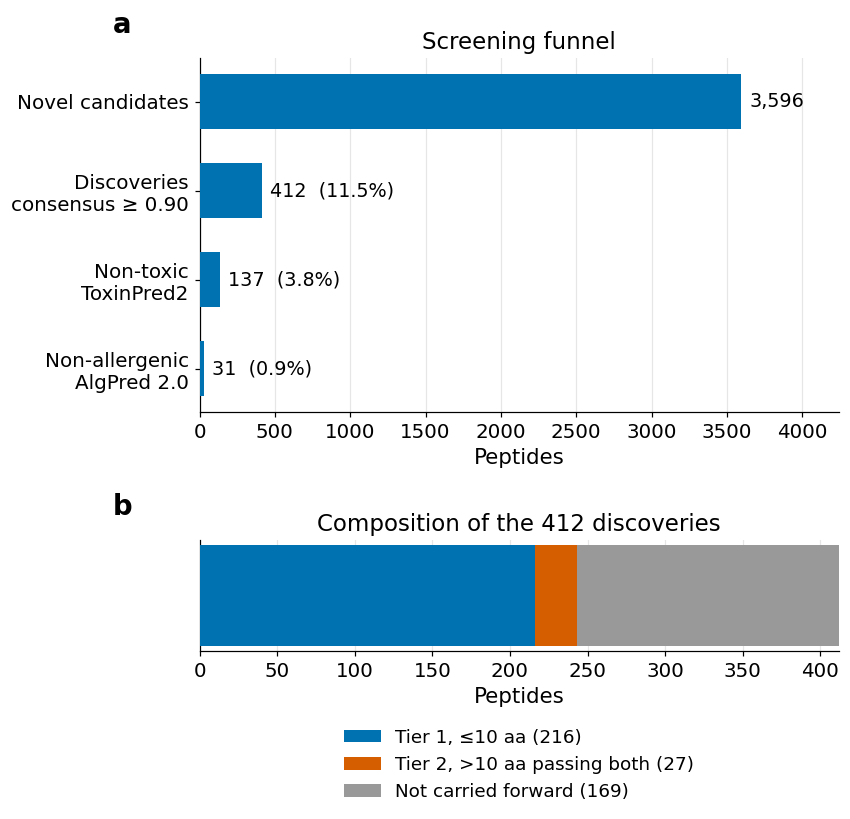

In [4]:
f = pd.read_csv("results/phase5_5_screening_funnel.csv").set_index("stage")["n"]

stages = [("Novel candidates", "novel_candidates"),
          ("Discoveries\nconsensus \u2265 0.90", "discoveries"),
          ("Non-toxic\nToxinPred2", "non_toxic"),
          ("Non-allergenic\nAlgPred 2.0", "non_toxic_non_allergen")]
labels, vals = [s[0] for s in stages], [int(f[s[1]]) for s in stages]

fig, (ax, bx) = plt.subplots(2, 1, figsize=(7.5, 7),
                             gridspec_kw={"height_ratios": [3.2, 1], "hspace": 0.55})

y = range(len(vals))
ax.barh(list(y), vals, color=BLUE, height=0.62, zorder=3)
ax.set_yticks(list(y), labels)
ax.invert_yaxis()
ax.set_xlim(0, max(vals) * 1.18)
ax.set_xlabel("Peptides")
ax.set_title("Screening funnel")
ax.grid(axis="y", visible=False)
for i, v in zip(y, vals):
    pct = 100 * v / vals[0]
    ax.text(v + max(vals) * 0.015, i, f"{v:,}" + (f"  ({pct:.1f}%)" if i else ""),
            va="center", fontsize=12.5)

# the tiers re-partition the discoveries, they do not continue the funnel
t1, t2 = int(f["tier1"]), int(f["tier2"])
rest = int(f["discoveries"]) - t1 - t2
segs = [(f"Tier 1, \u226410 aa ({t1})", t1, BLUE),
        (f"Tier 2, >10 aa passing both ({t2})", t2, VERMILLION),
        (f"Not carried forward ({rest})", rest, GREY)]
left = 0
for lab, v, c in segs:
    bx.barh([0], [v], left=left, color=c, height=0.5, label=lab, zorder=3)
    left += v
bx.set_yticks([])
bx.set_xlim(0, int(f["discoveries"]))
bx.set_xlabel("Peptides")
bx.set_title(f"Composition of the {int(f['discoveries'])} discoveries")
bx.grid(axis="y", visible=False)
bx.legend(loc="upper center", bbox_to_anchor=(0.5, -0.55), fontsize=12)
# panel letters, referenced as Figure 5a and 5b in the text
for lab, a in zip("ab", (ax, bx)):
    fig.text(0.02, a.get_position().y1 + 0.025, lab, fontsize=18, fontweight="bold", va="bottom")

save_figure(fig, "figure_5_screening_funnel")
plt.show()

## Further figures

following the pattern above: read an exported CSV, build, call `save_figure`. Candidates still to move in here are the negative-set length distribution, the charge against length control from Phase 6.4, the FVAPFPEVF alanine scan and the SHAP descriptor importances.